<a href="https://colab.research.google.com/github/m1naku/neuro/blob/main/NS_Domashnee_zadanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Домашнее задание №1
Определение тональности отзывов на фильмы с сайта IMDB
- IMDB обзоры фильмов классификация настроений
- Dataset состоит из 2х кортежей:
x_train, x_test: список последовательностей, которые являются списками индексов (целых чисел). Каждый из наборов данных состоят из 25 000 обзоров фильмов из IMDB, с указанием тональности (положительным/отрицательным). Обзоры были предварительно обработаны, и каждый обзор кодируется как последовательность индексов слов (целых чисел). Для удобства слова индексируются по общей частоте в наборе данных, так что, например, целое число " 3 " кодирует 3-е наиболее частое слово в данных.
- Как правило, "0" не обозначает конкретное слово, а вместо этого используется для кодирования любого неизвестного слова.
y_train, y_test: список целых меток (1 - положительная или 0 - отрицательная тональность).

Раскодируем сообщения

Служебные коды:  
0 - символ заполнитель  
1 - начало последовательности  
2 - неизвестное слово  

#Задание
- 1) Обучить нейронную сеть (Dense и SimpleRNN) подобрав структуру для классификации тональности отзывов.
-2) Сравнить результат их работы на тестовой выборке.
-3) Выбрать два отзыва с сайта https://www.imdb.com/ к любым фильмам. Один отрицательный и один положительный.
-4) Подготовить данные и протестировать на нейронных сетях.

# В отчет
- программа
-структуры сетей
- графики обучения
- адрес с выбранными для тестирования отзывами
- код и результат тестирования выбранных отзывов

In [83]:
from keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding, SimpleRNN
from tensorflow.keras import utils
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt

## Загружаем данные

Данные подготовлены для максимального количества слов 20000.

In [84]:

num_words=20000

In [85]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

In [86]:
len(x_train)

25000

## Просмотр данных

In [87]:
index = 3
print(x_train[index])
print(y_train[index])

[1, 4, 18609, 16085, 33, 2804, 4, 2040, 432, 111, 153, 103, 4, 1494, 13, 70, 131, 67, 11, 61, 15305, 744, 35, 3715, 761, 61, 5766, 452, 9214, 4, 985, 7, 2, 59, 166, 4, 105, 216, 1239, 41, 1797, 9, 15, 7, 35, 744, 2413, 31, 8, 4, 687, 23, 4, 2, 7339, 6, 3693, 42, 38, 39, 121, 59, 456, 10, 10, 7, 265, 12, 575, 111, 153, 159, 59, 16, 1447, 21, 25, 586, 482, 39, 4, 96, 59, 716, 12, 4, 172, 65, 9, 579, 11, 6004, 4, 1615, 5, 2, 7, 5168, 17, 13, 7064, 12, 19, 6, 464, 31, 314, 11, 2, 6, 719, 605, 11, 8, 202, 27, 310, 4, 3772, 3501, 8, 2722, 58, 10, 10, 537, 2116, 180, 40, 14, 413, 173, 7, 263, 112, 37, 152, 377, 4, 537, 263, 846, 579, 178, 54, 75, 71, 476, 36, 413, 263, 2504, 182, 5, 17, 75, 2306, 922, 36, 279, 131, 2895, 17, 2867, 42, 17, 35, 921, 18435, 192, 5, 1219, 3890, 19, 2, 217, 4122, 1710, 537, 2, 1236, 5, 736, 10, 10, 61, 403, 9, 2, 40, 61, 4494, 5, 27, 4494, 159, 90, 263, 2311, 4319, 309, 8, 178, 5, 82, 4319, 4, 65, 15, 9225, 145, 143, 5122, 12, 7039, 537, 746, 537, 537, 15, 7979, 4

In [88]:
# загрузка словаря, где ключи - слова, а значения - частота использования слова
word_index = imdb.get_word_index()

In [89]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [90]:
# подготовка словаря, где ключи - частота использования слова, а значения - слова
reverse_word_index = {}
for key, value in word_index.items():
  reverse_word_index[value] = key

In [91]:
reverse_word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [92]:
reverse_word_index[2]

'and'

In [93]:
reverse_word_index[14-3]

'this'

In [94]:
index = 3
message = ''
for code in x_train[index]:
    word = reverse_word_index.get(code - 3, '?')
    message += word + ' '
print(x_train[index])
message

[1, 4, 18609, 16085, 33, 2804, 4, 2040, 432, 111, 153, 103, 4, 1494, 13, 70, 131, 67, 11, 61, 15305, 744, 35, 3715, 761, 61, 5766, 452, 9214, 4, 985, 7, 2, 59, 166, 4, 105, 216, 1239, 41, 1797, 9, 15, 7, 35, 744, 2413, 31, 8, 4, 687, 23, 4, 2, 7339, 6, 3693, 42, 38, 39, 121, 59, 456, 10, 10, 7, 265, 12, 575, 111, 153, 159, 59, 16, 1447, 21, 25, 586, 482, 39, 4, 96, 59, 716, 12, 4, 172, 65, 9, 579, 11, 6004, 4, 1615, 5, 2, 7, 5168, 17, 13, 7064, 12, 19, 6, 464, 31, 314, 11, 2, 6, 719, 605, 11, 8, 202, 27, 310, 4, 3772, 3501, 8, 2722, 58, 10, 10, 537, 2116, 180, 40, 14, 413, 173, 7, 263, 112, 37, 152, 377, 4, 537, 263, 846, 579, 178, 54, 75, 71, 476, 36, 413, 263, 2504, 182, 5, 17, 75, 2306, 922, 36, 279, 131, 2895, 17, 2867, 42, 17, 35, 921, 18435, 192, 5, 1219, 3890, 19, 2, 217, 4122, 1710, 537, 2, 1236, 5, 736, 10, 10, 61, 403, 9, 2, 40, 61, 4494, 5, 27, 4494, 159, 90, 263, 2311, 4319, 309, 8, 178, 5, 82, 4319, 4, 65, 15, 9225, 145, 143, 5122, 12, 7039, 537, 746, 537, 537, 15, 7979, 4

"? the scots excel at storytelling the traditional sort many years after the event i can still see in my mind's eye an elderly lady my friend's mother retelling the battle of ? she makes the characters come alive her passion is that of an eye witness one to the events on the ? heath a mile or so from where she lives br br of course it happened many years before she was born but you wouldn't guess from the way she tells it the same story is told in bars the length and ? of scotland as i discussed it with a friend one night in ? a local cut in to give his version the discussion continued to closing time br br stories passed down like this become part of our being who doesn't remember the stories our parents told us when we were children they become our invisible world and as we grow older they maybe still serve as inspiration or as an emotional reservoir fact and fiction blend with ? role models warning stories ? magic and mystery br br my name is ? like my grandfather and his grandfathe

In [95]:
y_train[index]

np.int64(1)

## Подготовка данных для нейронной сети

In [96]:
maxlen = 200

In [97]:
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

## Dense модель

In [98]:
model_dense = Sequential()
model_dense.add(Embedding(num_words, 50, input_length=maxlen))
model_dense.add(Flatten())
model_dense.add(Dense(5))
model_dense.add(Dense(1, activation='sigmoid'))

In [99]:
model_dense.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [100]:
history_dense = model_dense.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - accuracy: 0.7212 - loss: 0.5431 - val_accuracy: 0.8304 - val_loss: 0.3913
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.8704 - loss: 0.3127 - val_accuracy: 0.8540 - val_loss: 0.3419
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9267 - loss: 0.2012 - val_accuracy: 0.8532 - val_loss: 0.3486
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.9728 - loss: 0.1013 - val_accuracy: 0.8308 - val_loss: 0.4284
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.9924 - loss: 0.0388 - val_accuracy: 0.8424 - val_loss: 0.4335


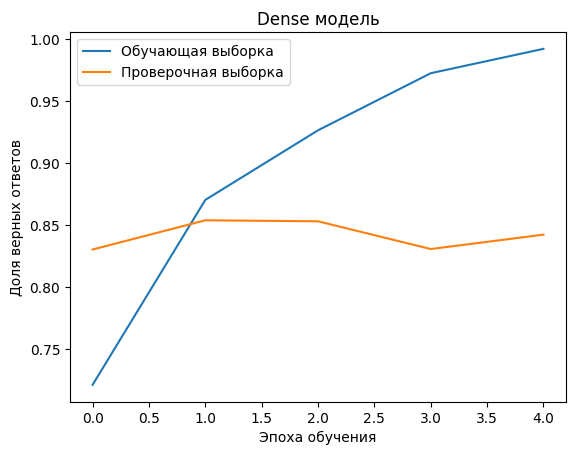

In [101]:
plt.plot(history_dense.history['accuracy'],
         label='Обучающая выборка')
plt.plot(history_dense.history['val_accuracy'],
         label='Проверочная выборка')
plt.title('Dense модель')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

## SimpleRNN модель

In [102]:
model_rnn = Sequential()
model_rnn.add(Embedding(num_words, 50, input_length=maxlen))
model_rnn.add(SimpleRNN(32))
model_rnn.add(Dense(1, activation='sigmoid'))

In [103]:
model_rnn.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [104]:
history_rnn = model_rnn.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.6673 - loss: 0.5924 - val_accuracy: 0.7788 - val_loss: 0.4744
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.8335 - loss: 0.3865 - val_accuracy: 0.7972 - val_loss: 0.4476
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.8700 - loss: 0.3133 - val_accuracy: 0.8212 - val_loss: 0.4598
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9033 - loss: 0.2467 - val_accuracy: 0.8724 - val_loss: 0.3421
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9359 - loss: 0.1718 - val_accuracy: 0.8512 - val_loss: 0.4111


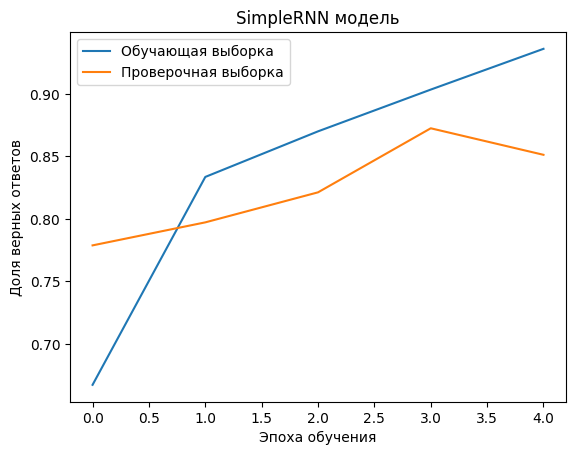

In [105]:
plt.plot(history_rnn.history['accuracy'],
         label='Обучающая выборка')
plt.plot(history_rnn.history['val_accuracy'],
         label='Проверочная выборка')
plt.title('SimpleRNN модель')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

## Сравнение на тестовой выборке

In [136]:
scores_dense = model_dense.evaluate(x_test, y_test, verbose=0)
scores_rnn = model_rnn.evaluate(x_test, y_test, verbose=0)
print("Dense  — точность: %.2f%%" % (scores_dense[1]*100))
print("SimpleRNN — точность: %.2f%%" % (scores_rnn[1]*100))

Dense  — точность: 84.48%
SimpleRNN — точность: 84.65%


## Тестирование на собственных отзывах (Начало)

In [107]:
# Начало (0.5/5)
# https://www.kinopoisk.ru/user/35236353/comment/2851693/
test = """After the arthouse Memento and the more traditional but no less magnificent Insomnia Nolan decided to switch to producing products aimed at the broad masses of the working people: Batman, Prestige (not a bad film, of course, but not an outstanding film either). Now this.

According to the plot, the characters of the picture are engaged in espionage, penetrating the dreams of their victims. Oh, so there will be dreams? A maze of surrealism, absurdity, understatement? Vain dreams, you might as well expect to be served a de flop of palaba with cacius seeds in a roadside shawarma. In the first half of the film, there will be an explanation, literally chewing through the laws of the dream world and the technological details of getting there. Otherwise, the viewer may not understand, 'no, they won't understand, Asia, sir.' There's a frustrating lack of surrealism, and even that one is too realistic. There are a lot of similar scenes going on, or not, it's not like that, one big scene with 'like an action movie', drawn out to the point of tediousness and a desire for it to end quickly, somehow, no matter how. It's over. 'Where's the gist of it, Lieutenant, where's the gist?'

In the "bottom line" we have either a semi-arthouse, semi-action movie, or an under-arthouse, under-action movie. You also need to be able to make films with shooting and explosions, and it's even possible that it requires no less (albeit peculiar) skill than a "highbrow" movie.

1 out of 10"""

In [108]:
# re.sub(pattern, repl, string, max=0)
# метод заменяет все вхождения pattern в string на repl, если не указано на max. Он возвращает измененную строку.
import re
test = re.sub('[,.\n]', ' ', test)

In [109]:
test = test.lower()

In [110]:
test

'after the arthouse memento and the more traditional but no less magnificent insomnia nolan decided to switch to producing products aimed at the broad masses of the working people: batman  prestige (not a bad film  of course  but not an outstanding film either)  now this   according to the plot  the characters of the picture are engaged in espionage  penetrating the dreams of their victims  oh  so there will be dreams? a maze of surrealism  absurdity  understatement? vain dreams  you might as well expect to be served a de flop of palaba with cacius seeds in a roadside shawarma  in the first half of the film  there will be an explanation  literally chewing through the laws of the dream world and the technological details of getting there  otherwise  the viewer may not understand  \'no  they won\'t understand  asia  sir \' there\'s a frustrating lack of surrealism  and even that one is too realistic  there are a lot of similar scenes going on  or not  it\'s not like that  one big scene w

In [111]:
test = test.split(' ')

In [112]:
test

['after',
 'the',
 'arthouse',
 'memento',
 'and',
 'the',
 'more',
 'traditional',
 'but',
 'no',
 'less',
 'magnificent',
 'insomnia',
 'nolan',
 'decided',
 'to',
 'switch',
 'to',
 'producing',
 'products',
 'aimed',
 'at',
 'the',
 'broad',
 'masses',
 'of',
 'the',
 'working',
 'people:',
 'batman',
 '',
 'prestige',
 '(not',
 'a',
 'bad',
 'film',
 '',
 'of',
 'course',
 '',
 'but',
 'not',
 'an',
 'outstanding',
 'film',
 'either)',
 '',
 'now',
 'this',
 '',
 '',
 'according',
 'to',
 'the',
 'plot',
 '',
 'the',
 'characters',
 'of',
 'the',
 'picture',
 'are',
 'engaged',
 'in',
 'espionage',
 '',
 'penetrating',
 'the',
 'dreams',
 'of',
 'their',
 'victims',
 '',
 'oh',
 '',
 'so',
 'there',
 'will',
 'be',
 'dreams?',
 'a',
 'maze',
 'of',
 'surrealism',
 '',
 'absurdity',
 '',
 'understatement?',
 'vain',
 'dreams',
 '',
 'you',
 'might',
 'as',
 'well',
 'expect',
 'to',
 'be',
 'served',
 'a',
 'de',
 'flop',
 'of',
 'palaba',
 'with',
 'cacius',
 'seeds',
 'in',
 'a',

Кодирем текст

In [113]:
coded_text = [1]

In [114]:
for word in test:
    if word != '':
        word_code = word_index.get(word, 2)
        if word_code > num_words:
            word_code = 2
        if word_code != 2:
          word_code += 3
        coded_text.append(word_code)


In [115]:
print(coded_text)

[1, 103, 4, 16719, 19497, 2, 4, 53, 2040, 21, 57, 329, 2000, 6811, 5705, 872, 8, 4416, 8, 4037, 7016, 3711, 33, 4, 3826, 5075, 7, 4, 780, 2, 1354, 18878, 2, 6, 78, 22, 7, 265, 21, 24, 35, 1339, 22, 2, 150, 14, 1793, 8, 4, 114, 4, 105, 7, 4, 431, 26, 3953, 11, 7825, 17418, 4, 1306, 7, 68, 1484, 449, 38, 50, 80, 30, 2, 6, 11917, 7, 10248, 5316, 2, 6080, 1306, 25, 238, 17, 73, 535, 8, 30, 3009, 6, 852, 4060, 7, 2, 19, 2, 12305, 11, 6, 2, 2, 11, 4, 86, 320, 7, 4, 22, 50, 80, 30, 35, 1823, 1227, 7605, 143, 4, 4461, 7, 4, 925, 182, 2, 4, 9603, 1373, 7, 397, 50, 900, 4, 529, 203, 24, 391, 14698, 36, 528, 391, 6490, 2688, 758, 225, 6, 5129, 583, 7, 10248, 2, 60, 15, 31, 9, 99, 821, 50, 26, 6, 176, 7, 729, 139, 170, 23, 42, 24, 45, 24, 40, 15, 31, 194, 136, 19, 2, 35, 206, 11605, 1309, 46, 8, 4, 213, 7, 2, 2, 6, 1762, 18, 12, 8, 130, 946, 820, 57, 551, 89, 45, 120, 2, 4, 15056, 7, 12, 9280, 6214, 4, 2, 11, 4, 2, 2, 75, 28, 345, 6, 2, 2, 20, 42, 35, 2, 2, 20, 25, 82, 359, 8, 30, 502, 8, 97, 108,

Преобразуем текст в массив numpy

In [116]:
x = np.array(coded_text)

In [117]:
x = np.expand_dims(x, axis=0)

In [118]:
x.shape

(1, 255)

In [119]:
x = pad_sequences(x, maxlen=200)

In [120]:
predictions_dense = model_dense.predict(x)
predictions_rnn = model_rnn.predict(x)
print("Отрицательный отзыв:")
print("Dense:", predictions_dense.round(), "(0=негативный, 1=позитивный)")
print("SimpleRNN:", predictions_rnn.round(), "(0=негативный, 1=позитивный)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
Отрицательный отзыв:
Dense: [[0.]] (0=негативный, 1=позитивный)
SimpleRNN: [[0.]] (0=негативный, 1=позитивный)


---

In [121]:
# Начало положительный отзыв (5/5)
# https://www.kinopoisk.ru/user/677443/comment/925741/
test = """Christopher Nolan is regularly given a pig after every one of his films. Moreover, over and over again, it is not the detractors of his work who do this, but his admirers, as a rule, even enthusiastic ones. After watching a lot of simple summer blockbusters, they label the director's work as "smart cinema", which they are by no means. Upon hearing about this, but not finding anything like it, advanced viewers get angry and swear. And the director just regularly shoots smart, but obviously entertaining pictures. But the way everyone else has already forgotten how.

The Beginning introduces one elementary idea into the viewer's subconscious. Like any thought, it takes time to mature, and the two and a half hours that the film is running is quite enough for that. Having finally formed, she rushes into consciousness at the end credits and says the following: 'Inception' is a very simple film. All of its seemingly complex levels are nothing more than layers of an onion that will be eaten anyway. He doesn't ask any big questions, he doesn't make you think deeply. There's not even any mindfuck, with Nolan's only ambiguity slightly teasing his audience.

Therefore, while watching this movie, appreciate every episode. Savor the mesmerizing shots where the amount of traditional visual effects is kept to a minimum. Enjoy the amazing harmony of Hans Zimmer's video and music. Marvel at the acting skills in those moments when tears come to the eyes of Leo DiCaprio and Cillian Murphy. Don't eat this onion, eat it. After all, when everything is over, a Thought will Appear, this harmful parasite, and inform you that, in general, you did not see anything unusual.

Although even she is not able to keep from the desire to immediately appreciate all this luxury again."""

In [122]:
# re.sub(pattern, repl, string, max=0)
# метод заменяет все вхождения pattern в string на repl, если не указано на max. Он возвращает измененную строку.
import re
test = re.sub('[,.\n]', ' ', test)

In [123]:
test = test.lower()

In [124]:
test

'christopher nolan is regularly given a pig after every one of his films  moreover  over and over again  it is not the detractors of his work who do this  but his admirers  as a rule  even enthusiastic ones  after watching a lot of simple summer blockbusters  they label the director\'s work as "smart cinema"  which they are by no means  upon hearing about this  but not finding anything like it  advanced viewers get angry and swear  and the director just regularly shoots smart  but obviously entertaining pictures  but the way everyone else has already forgotten how   the beginning introduces one elementary idea into the viewer\'s subconscious  like any thought  it takes time to mature  and the two and a half hours that the film is running is quite enough for that  having finally formed  she rushes into consciousness at the end credits and says the following: \'inception\' is a very simple film  all of its seemingly complex levels are nothing more than layers of an onion that will be eat

In [125]:
test = test.split(' ')

In [126]:
test

['christopher',
 'nolan',
 'is',
 'regularly',
 'given',
 'a',
 'pig',
 'after',
 'every',
 'one',
 'of',
 'his',
 'films',
 '',
 'moreover',
 '',
 'over',
 'and',
 'over',
 'again',
 '',
 'it',
 'is',
 'not',
 'the',
 'detractors',
 'of',
 'his',
 'work',
 'who',
 'do',
 'this',
 '',
 'but',
 'his',
 'admirers',
 '',
 'as',
 'a',
 'rule',
 '',
 'even',
 'enthusiastic',
 'ones',
 '',
 'after',
 'watching',
 'a',
 'lot',
 'of',
 'simple',
 'summer',
 'blockbusters',
 '',
 'they',
 'label',
 'the',
 "director's",
 'work',
 'as',
 '"smart',
 'cinema"',
 '',
 'which',
 'they',
 'are',
 'by',
 'no',
 'means',
 '',
 'upon',
 'hearing',
 'about',
 'this',
 '',
 'but',
 'not',
 'finding',
 'anything',
 'like',
 'it',
 '',
 'advanced',
 'viewers',
 'get',
 'angry',
 'and',
 'swear',
 '',
 'and',
 'the',
 'director',
 'just',
 'regularly',
 'shoots',
 'smart',
 '',
 'but',
 'obviously',
 'entertaining',
 'pictures',
 '',
 'but',
 'the',
 'way',
 'everyone',
 'else',
 'has',
 'already',
 'forgott

Кодирем текст

In [127]:
coded_text = [1]

In [128]:
for word in test:
    if word != '':
        word_code = word_index.get(word, 2)
        if word_code > num_words:
            word_code = 2
        if word_code != 2:
          word_code += 3
        coded_text.append(word_code)


In [129]:
print(coded_text)

[1, 1368, 5705, 9, 6947, 348, 6, 4272, 103, 175, 31, 7, 27, 108, 5359, 120, 2, 120, 174, 12, 9, 24, 4, 13743, 7, 27, 157, 37, 81, 14, 21, 27, 11892, 17, 6, 2673, 60, 6515, 663, 103, 149, 6, 176, 7, 606, 1506, 7554, 36, 6049, 4, 2030, 157, 17, 2, 2, 63, 36, 26, 34, 57, 817, 725, 2231, 44, 14, 21, 24, 1556, 233, 40, 12, 4677, 797, 79, 1612, 2, 3874, 2, 4, 167, 43, 6947, 3234, 1393, 21, 540, 441, 1268, 21, 4, 96, 316, 334, 47, 460, 1551, 89, 4, 454, 4319, 31, 10075, 326, 83, 4, 5975, 10278, 40, 101, 197, 12, 304, 58, 8, 2700, 2, 4, 107, 2, 6, 320, 634, 15, 4, 22, 9, 620, 9, 179, 195, 18, 15, 260, 417, 5950, 59, 9481, 83, 6831, 33, 4, 130, 898, 2, 560, 4, 2, 2, 9, 6, 55, 606, 22, 32, 7, 94, 1573, 1315, 2191, 26, 164, 53, 74, 5888, 7, 35, 19672, 15, 80, 30, 4706, 553, 29, 152, 942, 101, 194, 1204, 29, 152, 97, 25, 104, 1685, 225, 24, 60, 101, 2, 19, 2, 64, 7345, 1076, 14754, 27, 311, 1617, 137, 149, 14, 20, 1144, 175, 390, 18774, 4, 6070, 665, 121, 4, 1166, 7, 2040, 1114, 302, 9, 828, 8, 6,

Преобразуем текст в массив numpy

In [130]:
x = np.array(coded_text)

In [131]:
x = np.expand_dims(x, axis=0)

In [132]:
x.shape

(1, 300)

In [133]:
x = pad_sequences(x, maxlen=200)

In [134]:
predictions_dense = model_dense.predict(x)
predictions_rnn = model_rnn.predict(x)
print("Положительный отзыв:")
print("Dense:", predictions_dense.round(), "(0=негативный, 1=позитивный)")
print("SimpleRNN:", predictions_rnn.round(), "(0=негативный, 1=позитивный)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Положительный отзыв:
Dense: [[1.]] (0=негативный, 1=позитивный)
SimpleRNN: [[1.]] (0=негативный, 1=позитивный)
